In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df= pd.read_csv('../dataset/Loan Approval Prediction (2).csv')

In [6]:
print(df.isnull().sum())

person_age                            0
person_income                         0
person_emp_exp                        0
loan_amnt                             0
loan_int_rate                         0
loan_percent_income                   0
cb_person_cred_hist_length            0
credit_score                          0
person_gender_male                    0
person_education_Bachelor             0
person_education_Doctorate            0
person_education_High School          0
person_education_Master               0
person_home_ownership_OTHER           0
person_home_ownership_OWN             0
person_home_ownership_RENT            0
loan_intent_EDUCATION                 0
loan_intent_HOMEIMPROVEMENT           0
loan_intent_MEDICAL                   0
loan_intent_PERSONAL                  0
loan_intent_VENTURE                   0
previous_loan_defaults_on_file_Yes    0
loan_status                           0
dtype: int64


In [7]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_male,person_education_Bachelor,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes,loan_status
count,70000.000000,7.000000e+04,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,27.673129,7.297948e+04,5.161043,10020.783871,11.673156,0.162010,5.826657,632.424429,0.463200,0.225586,...,0.001814,0.043943,0.559900,0.145614,0.078386,0.151443,0.121014,0.120043,0.326543,0.500000
std,5.691924,7.056432e+04,5.676875,6623.701599,3.005940,0.099094,3.687981,47.340891,0.498647,0.417970,...,0.042556,0.204969,0.496403,0.352722,0.268780,0.358483,0.326146,0.325014,0.468952,0.500004
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,4.175500e+04,1.000000,5000.000000,9.750000,0.080000,3.000000,603.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,6.102950e+04,4.000000,8457.500000,11.490000,0.140000,4.000000,638.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000
75%,30.000000,8.757300e+04,7.000000,14000.000000,13.861052,0.230000,8.000000,667.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


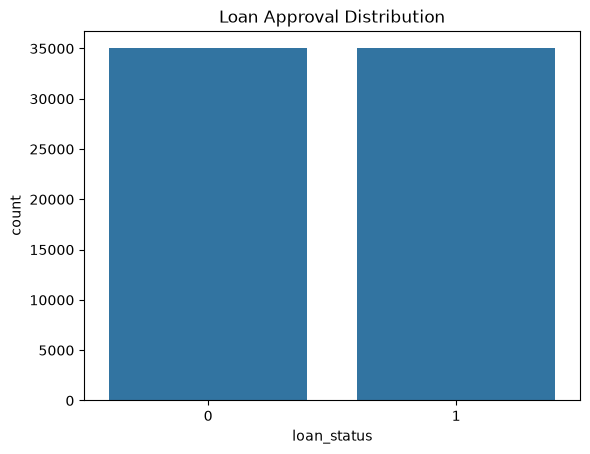

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loan_status', data=df)
plt.title('Loan Approval Distribution')
plt.show()

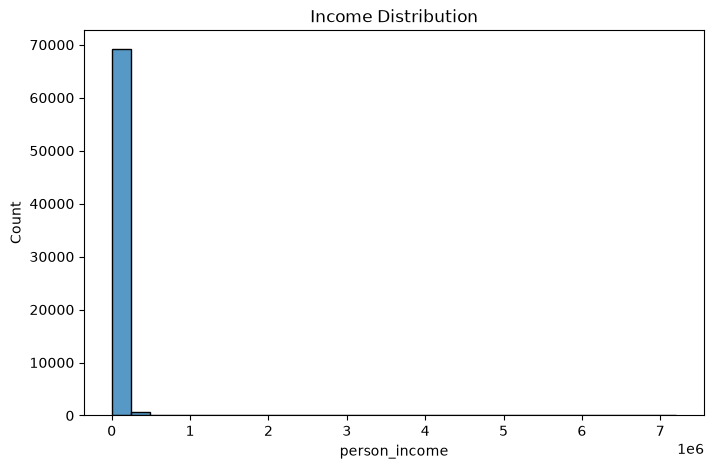

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['person_income'], bins=30)
plt.title('Income Distribution')
plt.show()

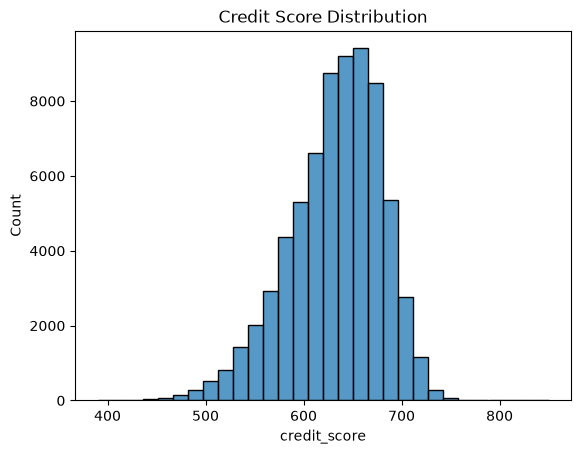

In [10]:
sns.histplot(df['credit_score'], bins=30)
plt.title('Credit Score Distribution')
plt.show()

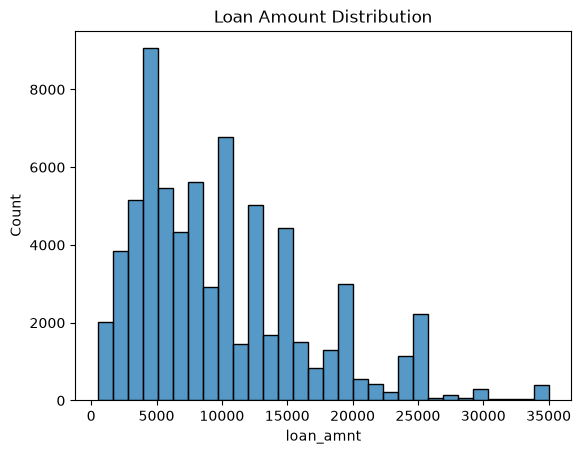

In [11]:
sns.histplot(df['loan_amnt'], bins=30)
plt.title('Loan Amount Distribution')
plt.show()

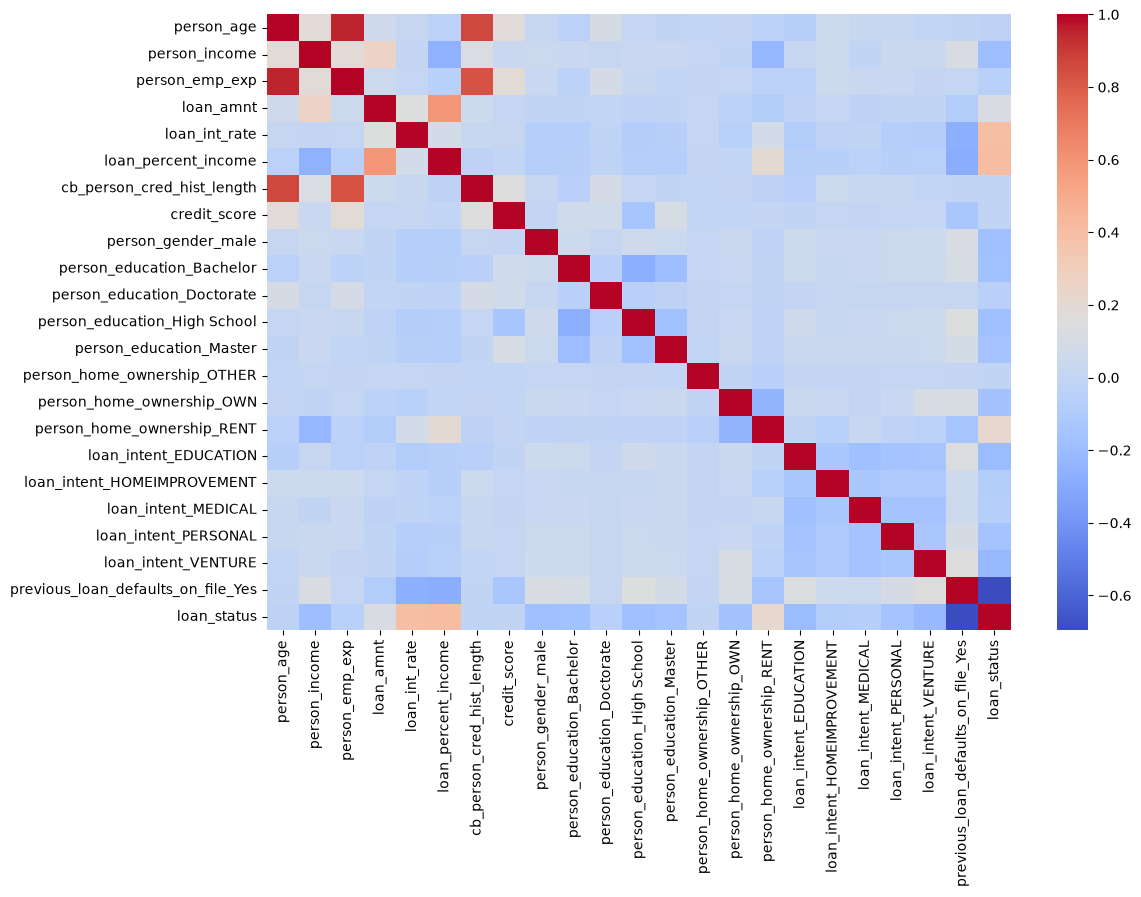

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

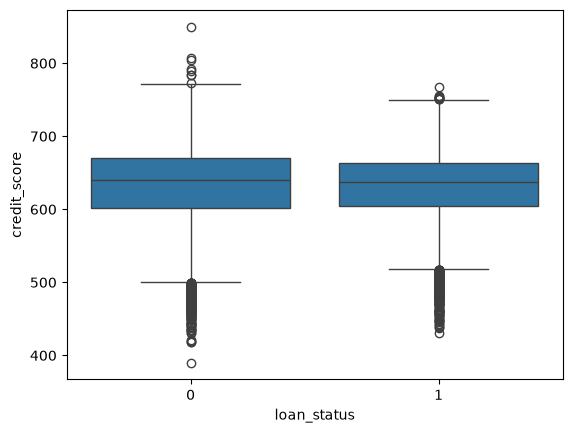

In [13]:
sns.boxplot(x='loan_status',
            y='credit_score',
            data=df)
plt.show()

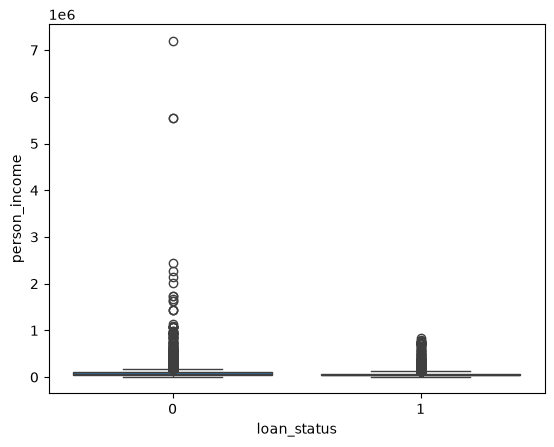

In [14]:
sns.boxplot(x='loan_status',
            y='person_income',
            data=df)
plt.show()

In [15]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_rf)

0.9404285714285714

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7023
           1       0.93      0.95      0.94      6977

    accuracy                           0.94     14000
   macro avg       0.94      0.94      0.94     14000
weighted avg       0.94      0.94      0.94     14000



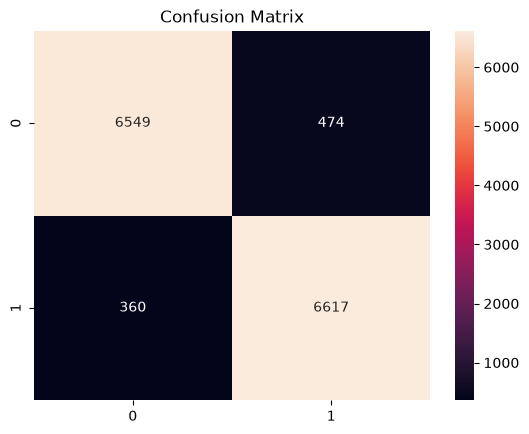

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.title('Confusion Matrix')
plt.show()

In [22]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
21,previous_loan_defaults_on_file_Yes,0.342175
4,loan_int_rate,0.135444
5,loan_percent_income,0.120052
1,person_income,0.095838
3,loan_amnt,0.044219
7,credit_score,0.036418
20,loan_intent_VENTURE,0.027187
15,person_home_ownership_RENT,0.023285
0,person_age,0.022173
16,loan_intent_EDUCATION,0.021317


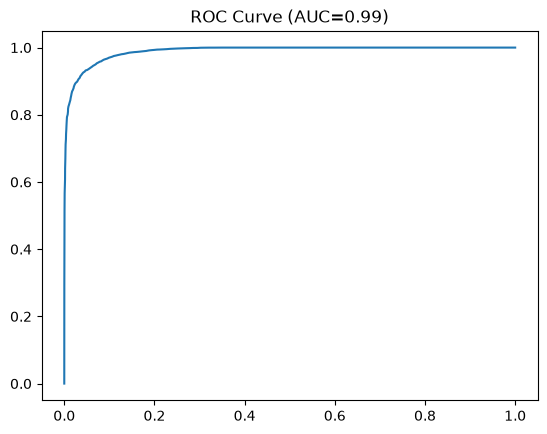

In [23]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC={roc_auc:.2f})")
plt.show()

In [25]:
import joblib

joblib.dump(rf, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']